# Phân Tích & Khai Phá Dữ Liệu Động Đất

## Earthquake Data Mining & Exploratory Data Analysis (EDA)

**Dữ liệu:** USGS Earthquake Catalog (1900-2024)  
**Tổng số records:** ~1.6 triệu events

In [1]:
# Import thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm, linregress

# Cấu hình hiển thị tiếng Việt
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

print("Đã import thư viện thành công!")

Đã import thư viện thành công!


## 1. TẢI DỮ LIỆU

In [2]:
# Đọc file CSV
df = pd.read_csv('data_summary.csv')

print(f"Kích thước dataset: {df.shape[0]:,} dòng x {df.shape[1]} cột")
print(f"\nCác cột: {list(df.columns)}")
print(f"\n5 dòng đầu tiên:")
df.head()

Kích thước dataset: 1,616,183 dòng x 9 cột

Các cột: ['mag', 'mag_range', 'depth', 'depth_range', 'year', 'month', 'lat', 'lon', 'place']

5 dòng đầu tiên:


,mag,mag_range,depth,depth_range,year,month,lat,lon,place
0,4.48,M4.0-5.0,6.0,Shallow (0-35km),1965.0,6.0,38.490,-119.1052,"39km SSE of Smith Valley, NV"
1,6.05,M6.0-7.0,25.0,Shallow (0-35km),1965.0,4.0,-42.704,174.2470,"119 km E of Hanmer Springs, New Zealand"
2,5.92,M5.0-6.0,35.0,Intermediate (35-70km),1965.0,2.0,-7.251,126.7150,"138 km NNE of Baukau, Timor Leste"
3,5.96,M5.0-6.0,14.0,Shallow (0-35km),1965.0,9.0,8.247,126.9460,"57 km E of Barcelona, Philippines"
4,4.90,M4.0-5.0,5.0,Shallow (0-35km),1965.0,10.0,44.713,-111.2720,"8 km SW of Hebgen Lake Estates, Montana"


In [3]:
# Thông tin dữ liệu
print("THÔNG TIN DỮ LIỆU:")
print("-" * 50)
df.info()

print("\nTHỐNG KÊ MÔ TẢ:")
print("-" * 50)
df.describe()

THÔNG TIN DỮ LIỆU:
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 1616183 entries, 0 to 1616182
Data columns (total 9 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   mag          1616183 non-null  float64
 1   mag_range    1616183 non-null  str    
 2   depth        1616183 non-null  float64
 3   depth_range  1616183 non-null  str    
 4   year         1616176 non-null  float64
 5   month        1616176 non-null  float64
 6   lat          1616183 non-null  float64
 7   lon          1616183 non-null  float64
 8   place        1616183 non-null  str    
dtypes: float64(6), str(3)
memory usage: 111.0 MB

THỐNG KÊ MÔ TẢ:
--------------------------------------------------


,mag,depth,year,month,lat,lon
count,1.616183e+06,1.616183e+06,1.616176e+06,1.616176e+06,1.616183e+06,1.616183e+06
mean,2.691945e+00,3.256929e+01,1.993911e+03,6.556603e+00,2.671360e+01,-6.370443e+01
std,1.534595e+00,8.113935e+01,1.419991e+01,3.439386e+00,2.393082e+01,1.051415e+02
min,-1.000000e+00,-1.000000e+01,1.900000e+03,1.000000e+00,-8.442200e+01,-1.799997e+02
25%,1.400000e+00,4.120000e+00,1.986000e+03,4.000000e+00,1.934120e+01,-1.219255e+02
50%,2.210000e+00,9.100000e+00,1.993000e+03,7.000000e+00,3.559600e+01,-1.176540e+02
75%,4.300000e+00,2.640000e+01,2.000000e+03,1.000000e+01,3.876500e+01,1.600000e+00
max,9.500000e+00,7.358000e+02,2.026000e+03,1.200000e+01,8.738600e+01,1.800000e+02


In [ ]:
# Kiểm tra missing values
print("KIỂM TRA DỮ LIỆU THIẾU:")
print("-" * 50)
missing = df.isnull().sum()
for col, count in missing[missing > 0].items():
    print(f"  {col}: {count:,} ({count/len(df)*100:.2f}%)")
if missing.sum() == 0:
    print("  Không có dữ liệu thiếu!")

## 2. THỐNG KÊ TỔNG QUAN

In [5]:
# Tính toán các chỉ số chính
total_events = len(df)
avg_mag = df['mag'].mean()
max_mag = df['mag'].max()
min_mag = df['mag'].min()
std_mag = df['mag'].std()
avg_depth = df['depth'].mean()
median_depth = df['depth'].median()
num_years = df['year'].nunique()
year_range = f"{int(df['year'].min())} - {int(df['year'].max())}"

print("=" * 70)
print("THỐNG KÊ TỔNG QUAN DỮ LIỆU ĐỘNG ĐẤT")
print("=" * 70)
print(f"\n📊 SỐ LƯỢNG:")
print(f"   Tổng số sự kiện:     {total_events:,}")
print(f"   Số năm:             {num_years}")
print(f"   Khoảng thời gian:   {year_range}")
print(f"   Trung bình/năm:     {total_events/num_years:,.0f}")

print(f"\n📈 ĐỘ LỚN (MAGNITUDE):")
print(f"   Trung bình:         {avg_mag:.2f}")
print(f"   Độ lệch chuẩn:      {std_mag:.2f}")
print(f"   Lớn nhất:           {max_mag:.2f}")
print(f"   Nhỏ nhất:           {min_mag:.2f}")
print(f"   Trung vị:           {df['mag'].median():.2f}")

print(f"\n🌍 ĐỘ SÂU (DEPTH):")
print(f"   Trung bình:         {avg_depth:.2f} km")
print(f"   Trung vị:           {median_depth:.2f} km")
print(f"   Sâu nhất:           {df['depth'].max():.2f} km")
print(f"   Nông nhất:          {df['depth'].min():.2f} km")

print("=" * 70)

THỐNG KÊ TỔNG QUAN DỮ LIỆU ĐỘNG ĐẤT

📊 SỐ LƯỢNG:
   Tổng số sự kiện:     1,616,183
   Số năm:             127
   Khoảng thời gian:   1900 - 2026
   Trung bình/năm:     12,726

📈 ĐỘ LỚN (MAGNITUDE):
   Trung bình:         2.69
   Độ lệch chuẩn:      1.53
   Lớn nhất:           9.50
   Nhỏ nhất:           -1.00
   Trung vị:           2.21

🌍 ĐỘ SÂU (DEPTH):
   Trung bình:         32.57 km
   Trung vị:           9.10 km
   Sâu nhất:           735.80 km
   Nông nhất:          -10.00 km


## 3. PHÂN PHỐI ĐỘ LỚN (MAGNITUDE DISTRIBUTION)

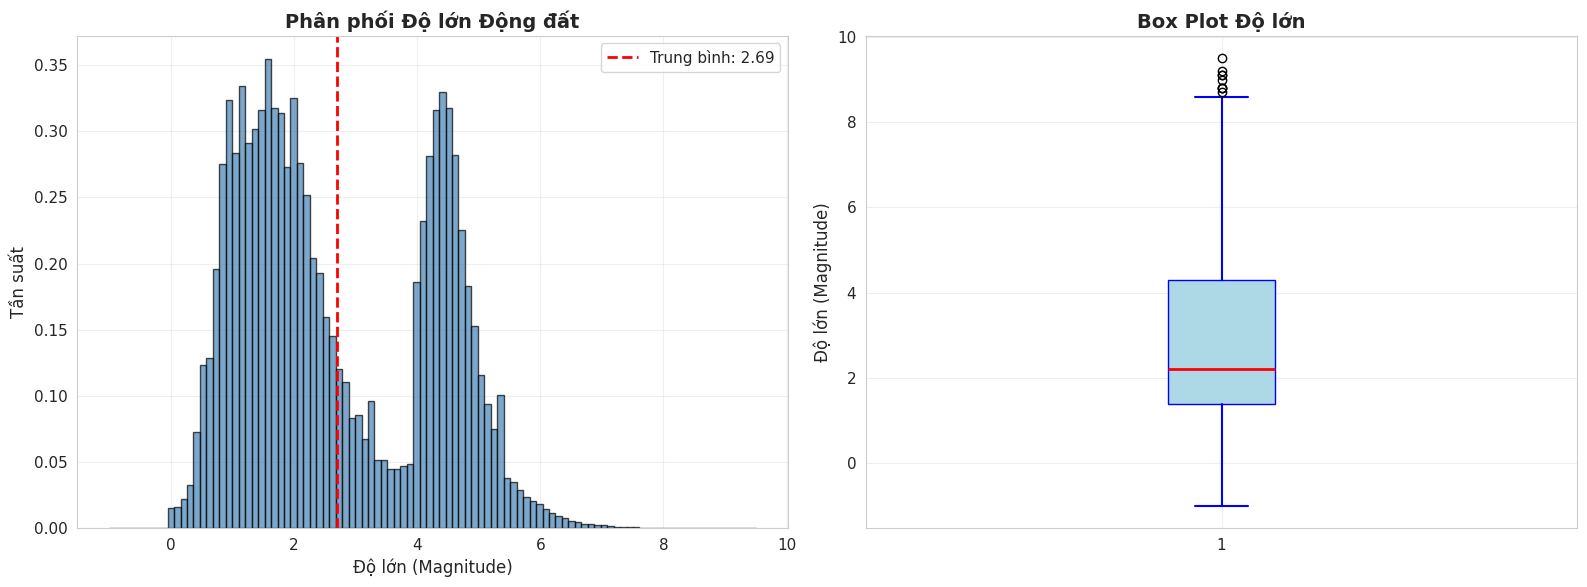

In [6]:
# Histogram và Box plot Độ lớn
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
axes[0].hist(df['mag'], bins=100, color='steelblue', edgecolor='black', alpha=0.7, density=True)
axes[0].set_xlabel('Độ lớn (Magnitude)', fontsize=12)
axes[0].set_ylabel('Tần suất', fontsize=12)
axes[0].set_title('Phân phối Độ lớn Động đất', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Thêm đường trung bình
axes[0].axvline(avg_mag, color='red', linestyle='--', linewidth=2, label=f'Trung bình: {avg_mag:.2f}')
axes[0].legend()

# Box plot
axes[1].boxplot(df['mag'], vert=True, patch_artist=True,
               boxprops=dict(facecolor='lightblue', color='blue'),
               medianprops=dict(color='red', linewidth=2),
               whiskerprops=dict(color='blue', linewidth=1.5),
               capprops=dict(color='blue', linewidth=1.5))
axes[1].set_ylabel('Độ lớn (Magnitude)', fontsize=12)
axes[1].set_title('Box Plot Độ lớn', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

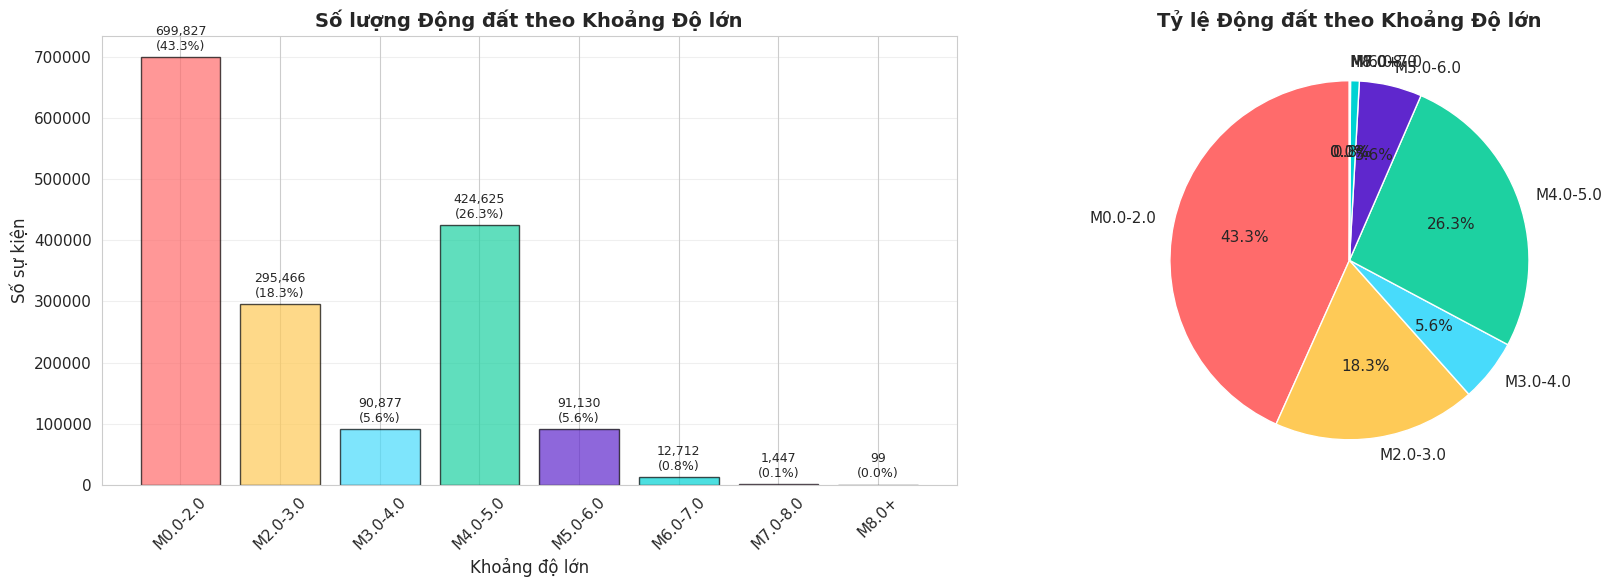


CHI TIẾT PHÂN PHỐI THEO ĐỘ LỚN:
--------------------------------------------------
  M0.0-2.0:         699,827 ( 43.30%)
  M2.0-3.0:         295,466 ( 18.28%)
  M3.0-4.0:          90,877 (  5.62%)
  M4.0-5.0:         424,625 ( 26.27%)
  M5.0-6.0:          91,130 (  5.64%)
  M6.0-7.0:          12,712 (  0.79%)
  M7.0-8.0:           1,447 (  0.09%)
  M8.0+:              99 (  0.01%)


In [7]:
# Phân phối theo khoảng độ lớn
mag_order = ['M0.0-2.0', 'M2.0-3.0', 'M3.0-4.0', 'M4.0-5.0', 'M5.0-6.0', 'M6.0-7.0', 'M7.0-8.0', 'M8.0+']
mag_counts = df['mag_range'].value_counts()
mag_counts = mag_counts.reindex(mag_order, fill_value=0)

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

colors = ['#ff6b6b', '#feca57', '#48dbfb', '#1dd1a1', '#5f27cd', '#00d2d3', '#ff9ff3', '#54a0ff']
bars = axes[0].bar(range(len(mag_counts)), mag_counts.values, color=colors, alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Khoảng độ lớn', fontsize=12)
axes[0].set_ylabel('Số sự kiện', fontsize=12)
axes[0].set_title('Số lượng Động đất theo Khoảng Độ lớn', fontsize=14, fontweight='bold')
axes[0].set_xticks(range(len(mag_counts)))
axes[0].set_xticklabels(mag_counts.index, rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# Thêm số liệu trên từng cột
for i, (bar, count) in enumerate(zip(bars, mag_counts.values)):
    if count > 0:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(mag_counts.values)*0.01,
                    f'{count:,}\n({count/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=9)

# Pie chart
mag_counts_nonzero = mag_counts[mag_counts > 0]
axes[1].pie(mag_counts_nonzero.values, labels=mag_counts_nonzero.index, autopct='%1.1f%%',
           startangle=90, colors=colors[:len(mag_counts_nonzero)])
axes[1].set_title('Tỷ lệ Động đất theo Khoảng Độ lớn', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nCHI TIẾT PHÂN PHỐI THEO ĐỘ LỚN:")
print("-" * 50)
for mag_range, count in mag_counts.items():
    print(f"  {mag_range}: {count:>15,} ({count/len(df)*100:>6.2f}%)")

## 4. PHÂN TÍCH THEO THỜI GIAN (TEMPORAL ANALYSIS)

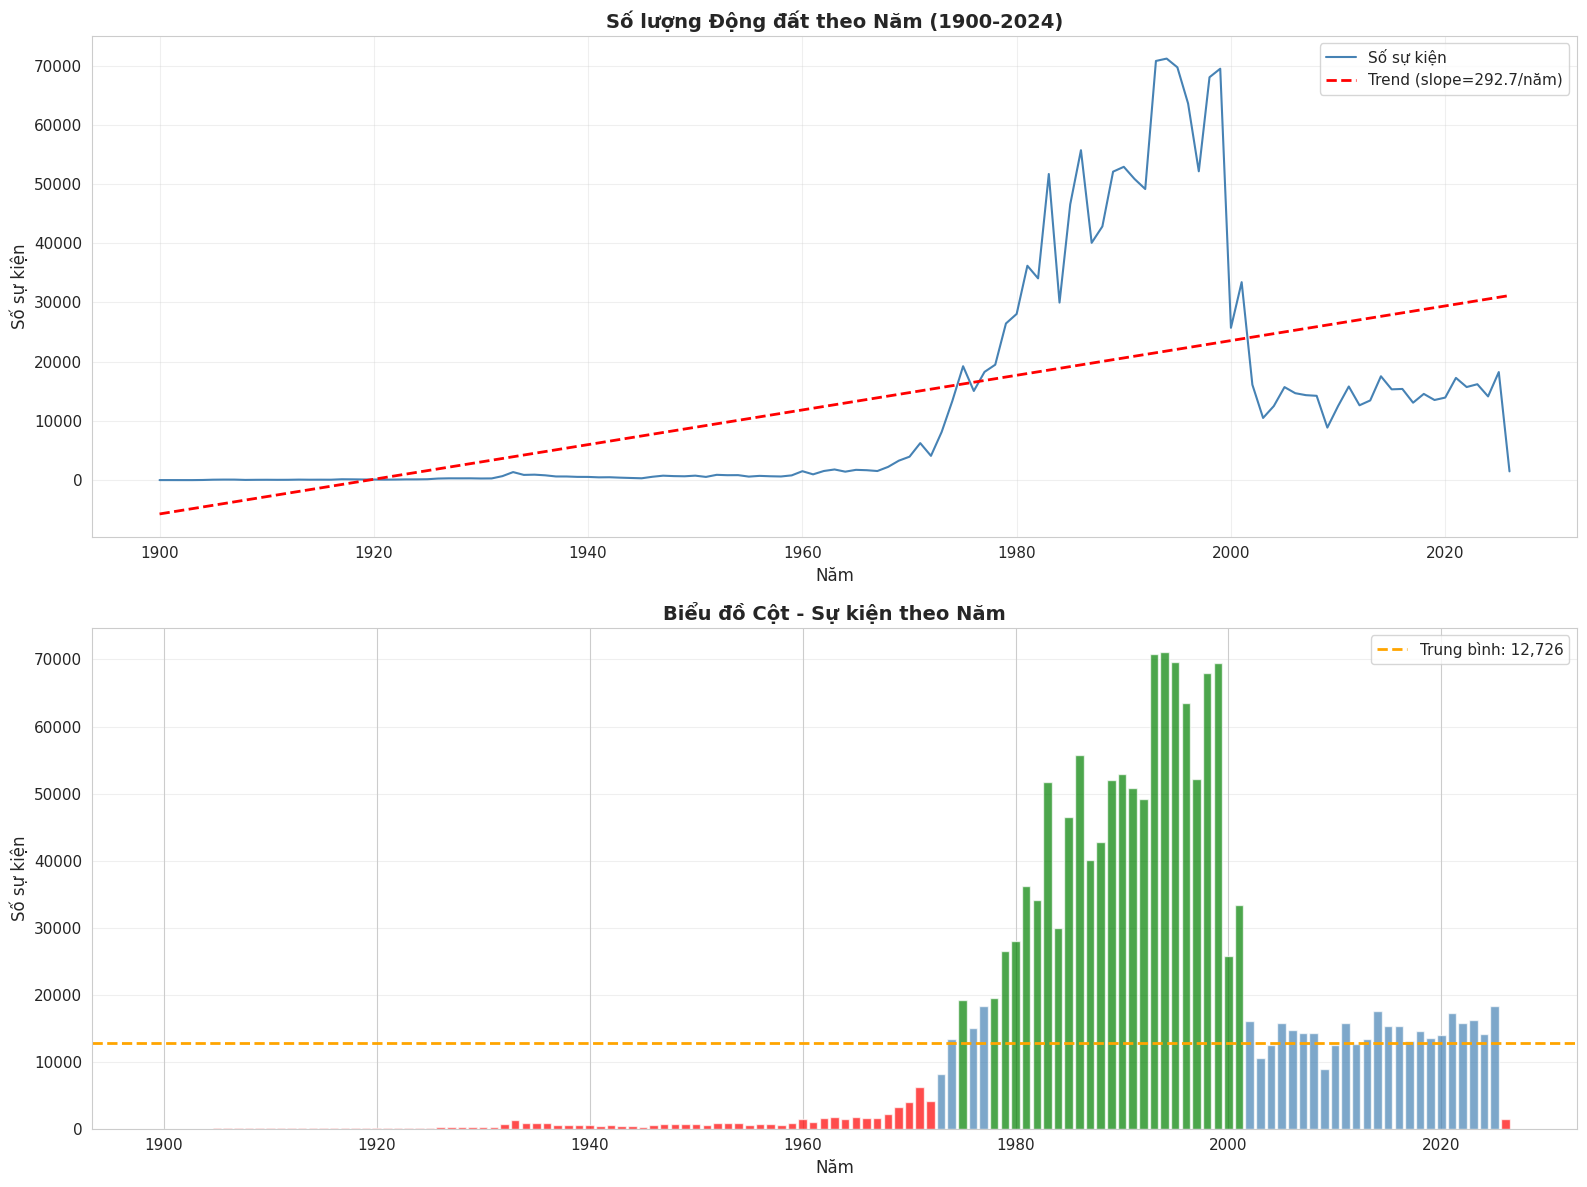


THÔNG TIN XU HƯỚNG:
  Trend: Tăng 292.7 sự kiện/năm
  Năm nhiều nhất: 1994.0 (71,165)
  Năm ít nhất: 1903.0 (2)


In [8]:
# Số sự kiện theo năm
yearly_counts = df.groupby('year').size().reset_index(name='count')

# Tìm trend
x = yearly_counts['year'].values
y = yearly_counts['count'].values
slope, intercept, r_value, p_value, std_err = linregress(x, y)
trend_line = slope * x + intercept

# Vẽ chart
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# Line chart
axes[0].plot(yearly_counts['year'], yearly_counts['count'], color='steelblue', linewidth=1.5, label='Số sự kiện')
axes[0].plot(yearly_counts['year'], trend_line, color='red', linestyle='--', linewidth=2,
           label=f'Trend (slope={slope:.1f}/năm)')
axes[0].set_xlabel('Năm', fontsize=12)
axes[0].set_ylabel('Số sự kiện', fontsize=12)
axes[0].set_title('Số lượng Động đất theo Năm (1900-2024)', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Bar chart - highlight các năm đặc biệt
mean_count = yearly_counts['count'].mean()
colors_bar = ['green' if c > mean_count*1.5 else 'red' if c < mean_count*0.5 else 'steelblue' for c in yearly_counts['count']]
axes[1].bar(yearly_counts['year'], yearly_counts['count'], color=colors_bar, alpha=0.7, width=0.8)
axes[1].axhline(mean_count, color='orange', linestyle='--', linewidth=2, label=f'Trung bình: {mean_count:,.0f}')
axes[1].set_xlabel('Năm', fontsize=12)
axes[1].set_ylabel('Số sự kiện', fontsize=12)
axes[1].set_title('Biểu đồ Cột - Sự kiện theo Năm', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nTHÔNG TIN XU HƯỚNG:")
print(f"  Trend: {'Tăng' if slope > 0 else 'Giảm'} {abs(slope):.1f} sự kiện/năm")
print(f"  Năm nhiều nhất: {yearly_counts.loc[yearly_counts['count'].idxmax(), 'year']} ({yearly_counts['count'].max():,})")
print(f"  Năm ít nhất: {yearly_counts.loc[yearly_counts['count'].idxmin(), 'year']} ({yearly_counts['count'].min():,})")

In [ ]:
# Phân tích theo tháng (tất cả các năm)
monthly_counts = df.groupby('month').size().reset_index(name='count')
months = ['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9', 'T10', 'T11', 'T12']

plt.figure(figsize=(12, 6))
bars = plt.bar(monthly_counts['month'], monthly_counts['count'], color='coral', alpha=0.7, edgecolor='black')
plt.xlabel('Tháng', fontsize=12)
plt.ylabel('Số sự kiện', fontsize=12)
plt.title('Số lượng Động đất theo Tháng (Tất cả các năm)', fontsize=14, fontweight='bold')
plt.xticks(range(1, 13), months)
plt.grid(True, alpha=0.3, axis='y')

# Thêm trend line
z = np.polyfit(monthly_counts['month'], monthly_counts['count'], 2)
p = np.poly1d(z)
plt.plot(monthly_counts['month'], p(monthly_counts['month']), "r--", linewidth=2, alpha=0.5, label='Trend')
plt.legend()

plt.tight_layout()
plt.show()

print("\nPHÂN BỔ THEO THÁNG:")
print("-" * 40)
for month, count in zip(months, monthly_counts['count']):
    print(f"  {month}: {count:>15,} ({count/len(df)*100:>5.2f}%)")

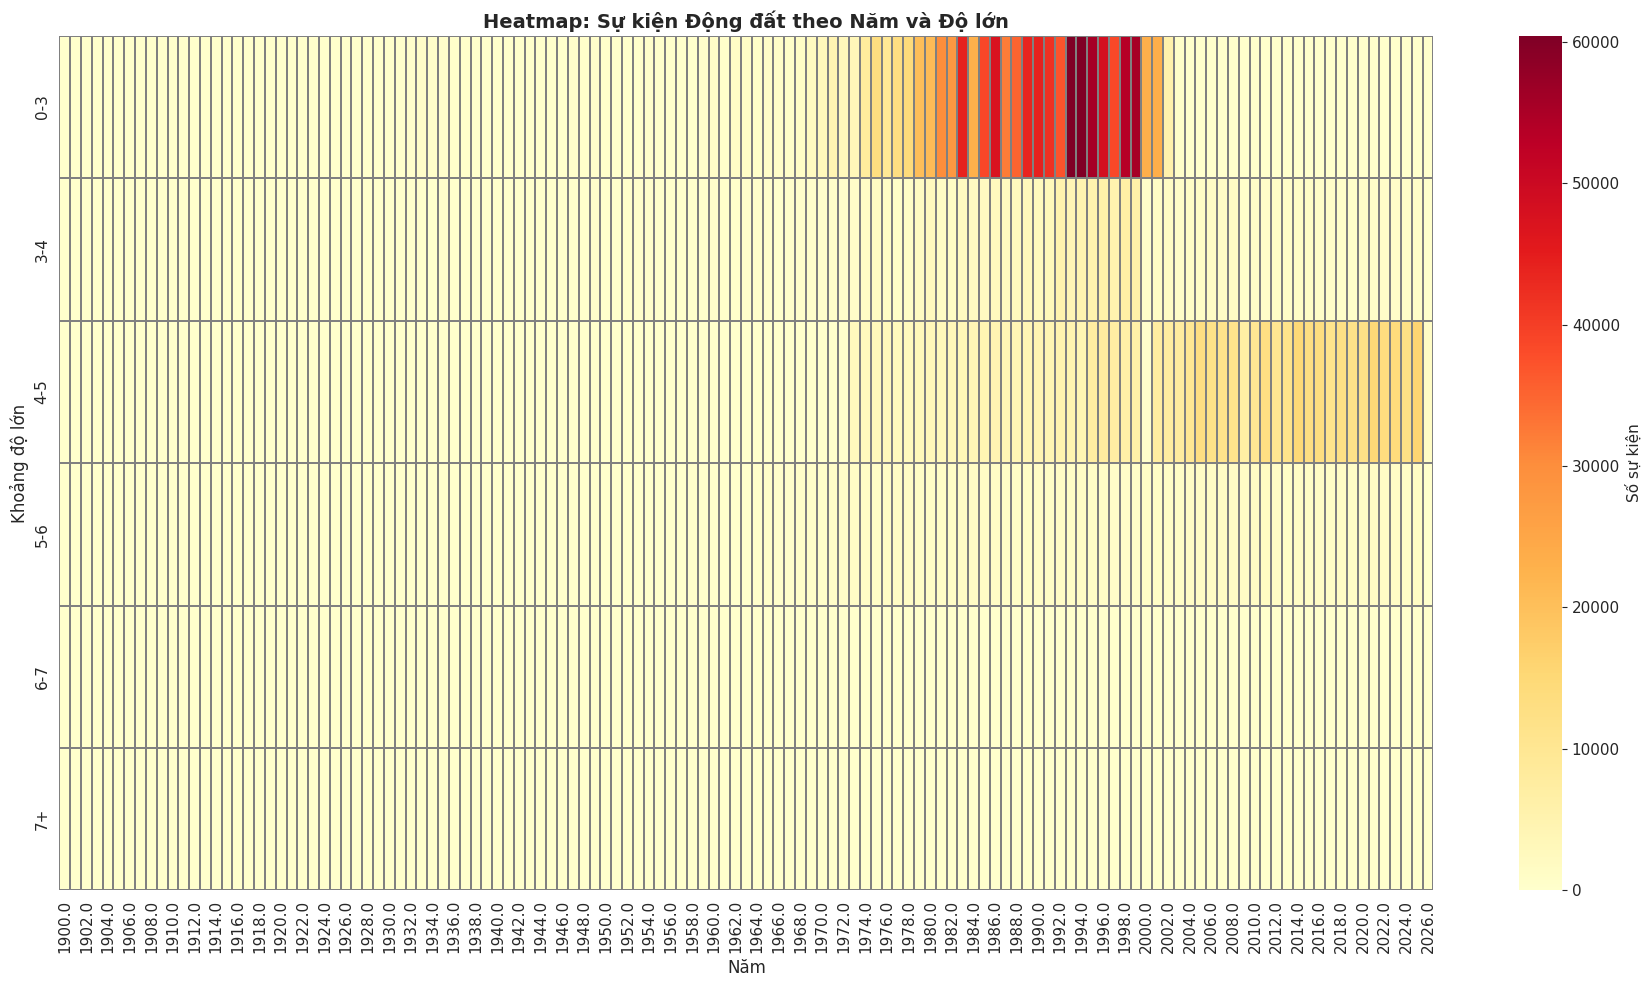

In [10]:
# Heatmap: Năm x Khoảng độ lớn
df['mag_bin'] = pd.cut(df['mag'], bins=[0, 3, 4, 5, 6, 7, 10],
                         labels=['0-3', '3-4', '4-5', '5-6', '6-7', '7+'])

pivot = df.groupby(['year', 'mag_bin']).size().unstack(fill_value=0)

plt.figure(figsize=(18, 10))
sns.heatmap(pivot.T, cmap='YlOrRd', cbar_kws={'label': 'Số sự kiện'},
           linewidths=0.1, linecolor='gray')
plt.xlabel('Năm', fontsize=12)
plt.ylabel('Khoảng độ lớn', fontsize=12)
plt.title('Heatmap: Sự kiện Động đất theo Năm và Độ lớn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. PHÂN TÍCH ĐỘ SÂU (DEPTH ANALYSIS)

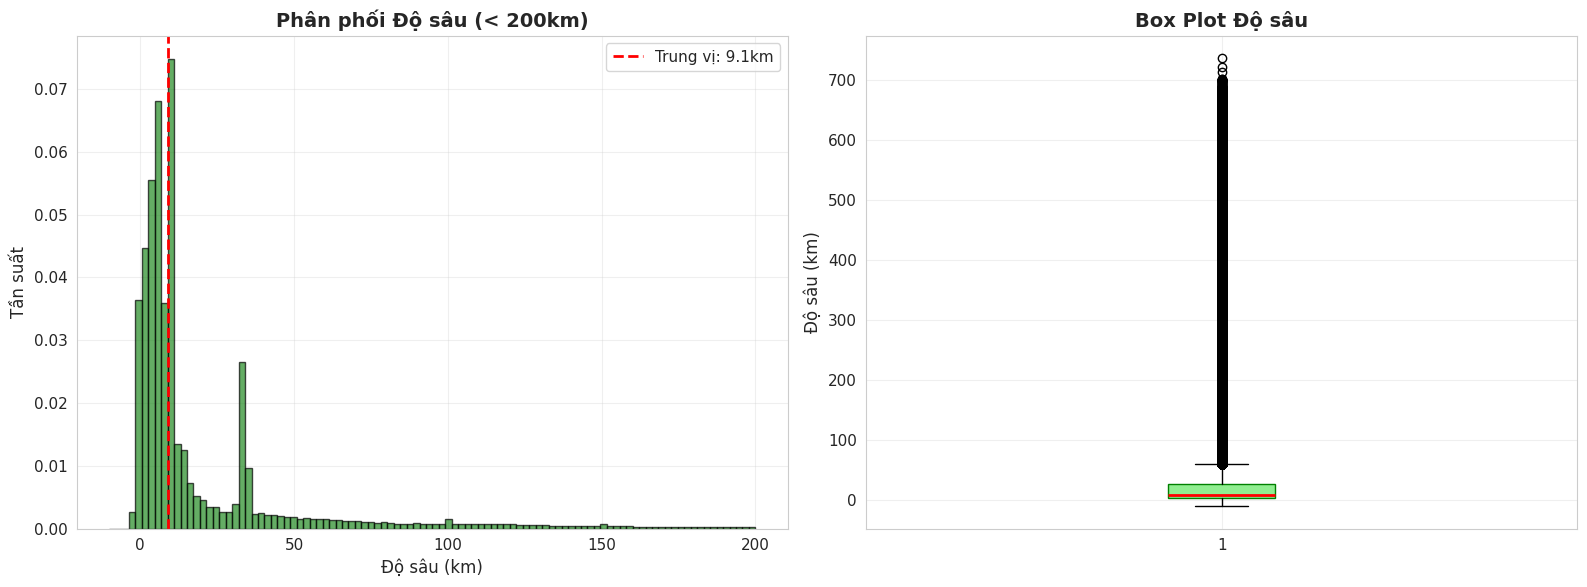

In [11]:
# Phân phối Độ sâu
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram (chỉ lấy depth < 200km để dễ nhìn)
depth_subset = df[df['depth'] < 200]['depth']
axes[0].hist(depth_subset, bins=100, color='forestgreen', edgecolor='black', alpha=0.7, density=True)
axes[0].set_xlabel('Độ sâu (km)', fontsize=12)
axes[0].set_ylabel('Tần suất', fontsize=12)
axes[0].set_title('Phân phối Độ sâu (< 200km)', fontsize=14, fontweight='bold')
axes[0].axvline(median_depth, color='red', linestyle='--', linewidth=2, label=f'Trung vị: {median_depth:.1f}km')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot(df['depth'], vert=True, patch_artist=True,
               boxprops=dict(facecolor='lightgreen', color='green'),
               medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('Độ sâu (km)', fontsize=12)
axes[1].set_title('Box Plot Độ sâu', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Phân bố theo loại độ sâu
depth_counts = df['depth_range'].value_counts()
depth_order = ['Shallow (0-35km)', 'Intermediate (35-70km)', 'Deep (70-300km)', 'Very Deep (300km+)']
depth_counts = depth_counts.reindex(depth_order, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
colors_depth = ['#2ecc71', '#f39c12', '#e74c3c', '#9b59b6']
bars = axes[0].bar(range(len(depth_counts)), depth_counts.values, color=colors_depth, alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Loại độ sâu', fontsize=12)
axes[0].set_ylabel('Số sự kiện', fontsize=12)
axes[0].set_title('Phân bố theo Loại Độ sâu', fontsize=14, fontweight='bold')
axes[0].set_xticks(range(len(depth_counts)))
axes[0].set_xticklabels([d.replace('(', '\n(').replace(')', ')') for d in depth_counts.index])
axes[0].grid(True, alpha=0.3, axis='y')

# Thêm số liệu
for bar, count in zip(bars, depth_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(depth_counts.values)*0.01,
                f'{count:,}\n({count/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=10)

# Pie chart
axes[1].pie(depth_counts.values, labels=depth_counts.index, autopct='%1.1f%%',
           startangle=90, colors=colors_depth)
axes[1].set_title('Tỷ lệ theo Loại Độ sâu', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 6. MỐI TƯƠNG QUAN: ĐỘ LỚN vs ĐỘ SÂU

In [ ]:
# Scatter plot: Độ lớn vs Độ sâu
# Sample để hiển thị nhanh hơn
sample_size = min(50000, len(df))
sample_df = df.sample(n=sample_size, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot
scatter = axes[0].scatter(sample_df['depth'], sample_df['mag'],
                          c=sample_df['mag'], cmap='YlOrRd',
                          s=10, alpha=0.3, vmin=0, vmax=10)
axes[0].set_xlabel('Độ sâu (km)', fontsize=12)
axes[0].set_ylabel('Độ lớn', fontsize=12)
axes[0].set_title('Độ lớn vs Độ sâu', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[0], label='Độ lớn')

# 2D Histogram
h = axes[1].hist2d(sample_df['depth'], sample_df['mag'], bins=50, cmap='YlOrRd')
axes[1].set_xlabel('Độ sâu (km)', fontsize=12)
axes[1].set_ylabel('Độ lớn', fontsize=12)
axes[1].set_title('Heatmap: Độ lớn vs Độ sâu', fontsize=14, fontweight='bold')
plt.colorbar(h[3], ax=axes[1], label='Tần suất')

plt.tight_layout()
plt.show()

# Tính correlation
corr = df[['mag', 'depth']].corr().iloc[0, 1]
print(f"\nHệ số tương quan (Correlation): {corr:.3f}")
if abs(corr) < 0.1:
    print("=> Độ lớn và Độ sâu KHÔNG có mối tương quan rõ rệt")
elif corr > 0:
    print("=> Có tương quan dương yếu: Động đất sâu hơn thường mạnh hơn")
else:
    print("=> Có tương quan âm yếu: Động đất nông hơn thường mạnh hơn")

## 7. ĐỊNH LUẬT GUTENBERG-RICHTER

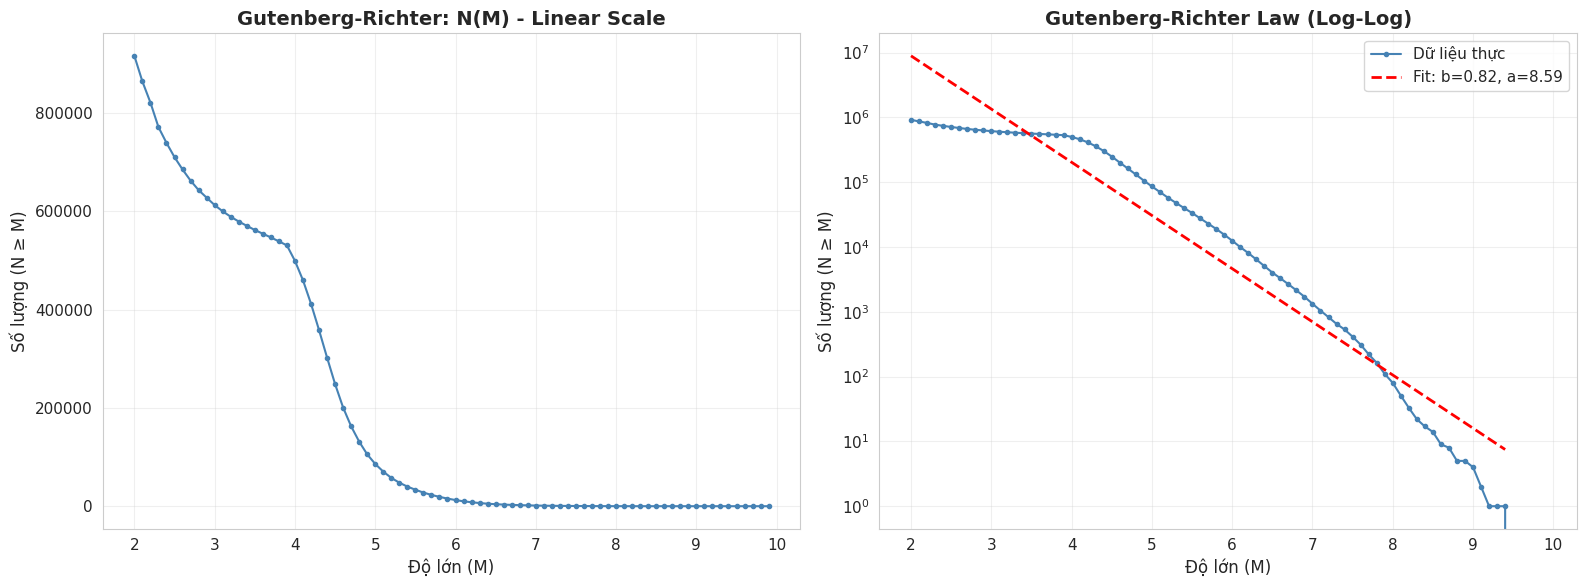


ĐỊNH LUẬT GUTENBERG-RICHTER:
  log10(N) = 8.59 - 0.82 * M
  b-value: 0.82

=> Với mỗi đơn vị độ lớn tăng thêm, số lượng động đất giảm 6.6 lần
=> b-value điển hình: 0.8 - 1.2 ( globally ~1.0)


In [14]:
# Phân tích Gutenberg-Richter Law: log10(N) = a - b*M
# N = số lượng động đất có độ lớn ≥ M

# Tính cumulative count
mag_bins = np.arange(2, 10, 0.1)
cumulative_counts = []
for m in mag_bins:
    count = len(df[df['mag'] >= m])
    cumulative_counts.append(count)

# Vẽ log-scale plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Linear scale
axes[0].plot(mag_bins, cumulative_counts, 'o-', color='steelblue', markersize=3)
axes[0].set_xlabel('Độ lớn (M)', fontsize=12)
axes[0].set_ylabel('Số lượng (N ≥ M)', fontsize=12)
axes[0].set_title('Gutenberg-Richter: N(M) - Linear Scale', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Log scale (để tính b-value)
log_counts = np.log10(np.array(cumulative_counts) + 1)
valid_idx = log_counts > 0  # Chỉ lấy giá trị hợp lệ
mag_valid = mag_bins[valid_idx]
log_valid = log_counts[valid_idx]

# Linear regression để tìm b-value
slope, intercept, r_value, p_value, std_err = linregress(mag_valid, log_valid)
b_value = -slope
a_value = intercept

axes[1].semilogy(mag_bins, cumulative_counts, 'o-', color='steelblue', markersize=3, label='Dữ liệu thực')
axes[1].semilogy(mag_valid, 10**(slope * mag_valid + intercept), 'r--', linewidth=2,
                label=f'Fit: b={b_value:.2f}, a={a_value:.2f}')
axes[1].set_xlabel('Độ lớn (M)', fontsize=12)
axes[1].set_ylabel('Số lượng (N ≥ M)', fontsize=12)
axes[1].set_title('Gutenberg-Richter Law (Log-Log)', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nĐỊNH LUẬT GUTENBERG-RICHTER:")
print(f"  log10(N) = {a_value:.2f} - {b_value:.2f} * M")
print(f"  b-value: {b_value:.2f}")
print(f"\n=> Với mỗi đơn vị độ lớn tăng thêm, số lượng động đất giảm {10**b_value:.1f} lần")
print(f"=> b-value điển hình: 0.8 - 1.2 ( globally ~1.0)")

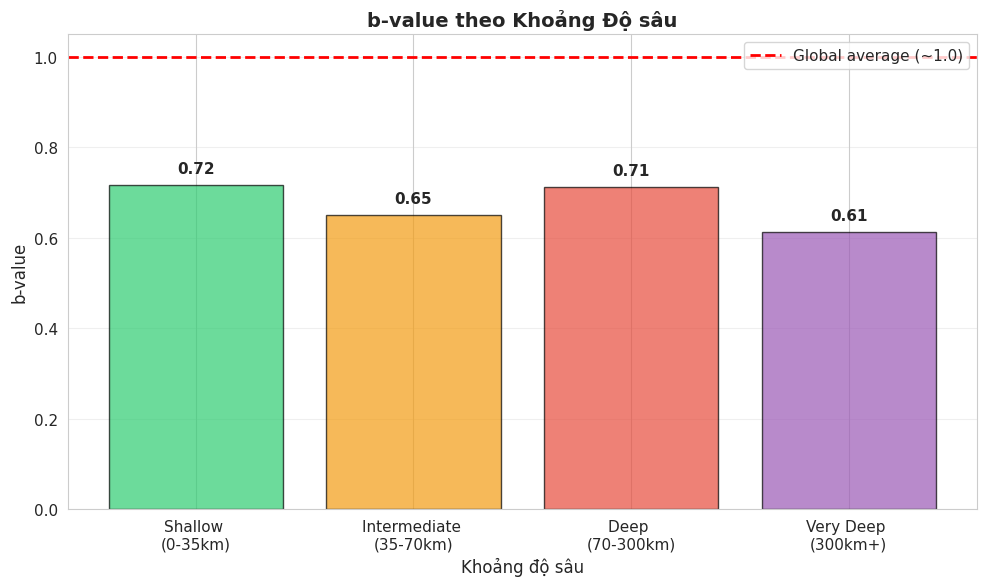


b-value THEO ĐỘ SÂU:
  Very Deep (300km+): b = 0.61
  Intermediate (35-70km): b = 0.65
  Deep (70-300km): b = 0.71
  Shallow (0-35km): b = 0.72


In [15]:
# b-value theo khoảng độ sâu
depth_ranges_b = {}
for depth_range in df['depth_range'].unique():
    subset = df[df['depth_range'] == depth_range]
    if len(subset) > 100:
        mag_bins = np.arange(2, 10, 0.2)
        cumulative_counts = [len(subset[subset['mag'] >= m]) for m in mag_bins]
        log_counts = np.log10(np.array(cumulative_counts) + 1)
        valid_idx = (log_counts > 0) & (np.array(cumulative_counts) > 10)
        
        if np.sum(valid_idx) > 5:
            slope, _, _, _, _ = linregress(mag_bins[valid_idx], log_counts[valid_idx])
            depth_ranges_b[depth_range] = -slope

# Vẽ b-value theo độ sâu
plt.figure(figsize=(10, 6))
b_values = list(depth_ranges_b.values())
labels = [d.replace('(', '\n(') for d in depth_ranges_b.keys()]
colors_b = ['#2ecc71', '#f39c12', '#e74c3c', '#9b59b6'][:len(b_values)]

bars = plt.bar(range(len(b_values)), b_values, color=colors_b, alpha=0.7, edgecolor='black')
plt.xlabel('Khoảng độ sâu', fontsize=12)
plt.ylabel('b-value', fontsize=12)
plt.title('b-value theo Khoảng Độ sâu', fontsize=14, fontweight='bold')
plt.xticks(range(len(b_values)), labels)
plt.axhline(1.0, color='red', linestyle='--', linewidth=2, label='Global average (~1.0)')
plt.grid(True, alpha=0.3, axis='y')
plt.legend()

# Thêm giá trị trên cột
for bar, val in zip(bars, b_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nb-value THEO ĐỘ SÂU:")
for depth_range, b_val in sorted(depth_ranges_b.items(), key=lambda x: x[1]):
    print(f"  {depth_range}: b = {b_val:.2f}")

## 8. CÁC ĐỘNG ĐẤT LỚN (MAJOR EARTHQUAKES)

In [16]:
# Các động đất lớn (M7.0+)
major_quakes = df[df['mag'] >= 7.0].sort_values('mag', ascending=False)

print(f"\nĐỘNG ĐẤT LỚN (M7.0+): {len(major_quakes)} sự kiện")
print("=" * 80)

# Top 20 động đất lớn nhất
top_major = major_quakes[['year', 'month', 'mag', 'depth', 'place']].head(20)
top_major.columns = ['Năm', 'Tháng', 'Độ lớn', 'Độ sâu (km)', 'Vị trí']
print(top_major.to_string(index=True))


ĐỘNG ĐẤT LỚN (M7.0+): 1546 sự kiện
            Năm  Tháng  Độ lớn  Độ sâu (km)                                                          Vị trí
748348   1960.0    5.0     9.5         25.0             1960 Great Chilean Earthquake (Valdivia Earthquake)
75778    1964.0    3.0     9.2         25.0                The 1964 Prince William Sound, Alaska Earthquake
1552173  2011.0    3.0     9.1         29.0                             2011 Great Tohoku Earthquake, Japan
965764   2004.0   12.0     9.1         30.0                       2004 Sumatra - Andaman Islands Earthquake
902291   1952.0   11.0     9.0         21.6                   89 km ESE of Petropavlovsk-Kamchatsky, Russia
409340   2025.0    7.0     8.8         35.0                     2025 Kamchatka Peninsula, Russia Earthquake
299217   1906.0    1.0     8.8         20.0                                1906 Ecuador-Colombia Earthquake
263366   2010.0    2.0     8.8         22.9                                    2010 Maule, Chile Ear

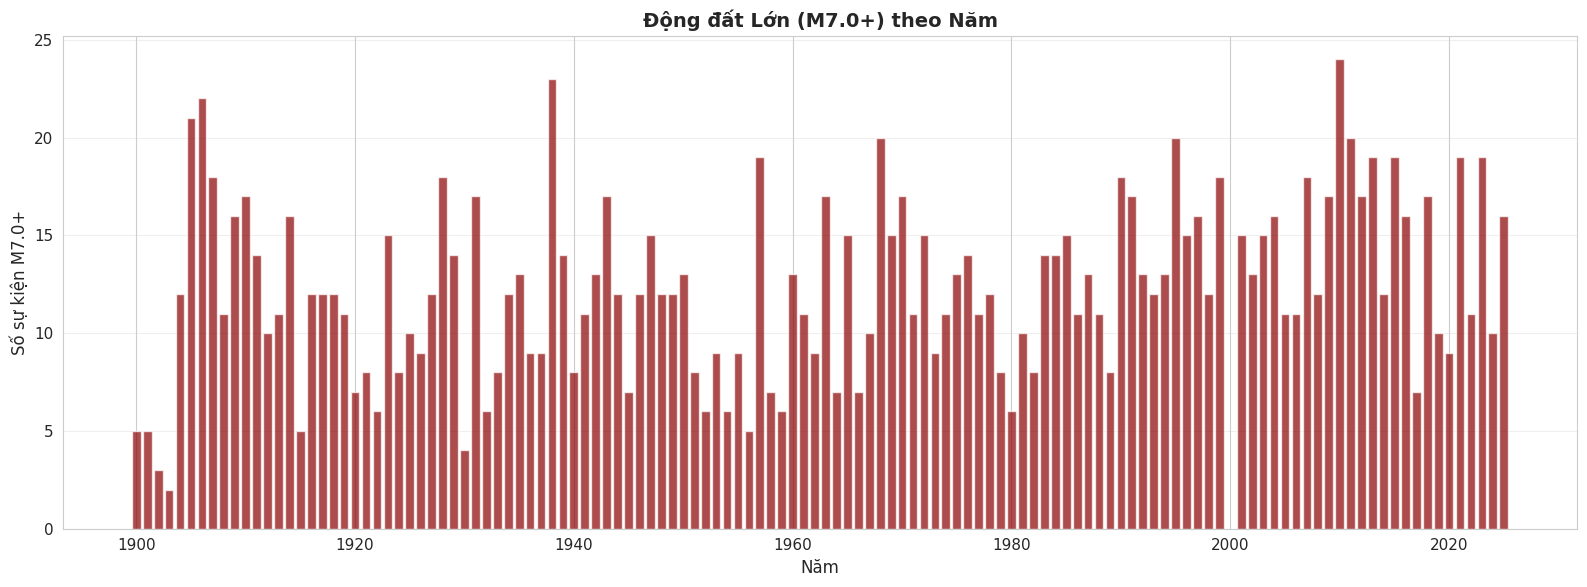


Trung bình: 12.2 động đất M7.0+/năm


In [17]:
# Phân bố động đất lớn theo năm
major_by_year = df[df['mag'] >= 7.0].groupby('year').size().reset_index(name='count')

plt.figure(figsize=(16, 6))
plt.bar(major_by_year['year'], major_by_year['count'], color='darkred', alpha=0.7)
plt.xlabel('Năm', fontsize=12)
plt.ylabel('Số sự kiện M7.0+', fontsize=12)
plt.title('Động đất Lớn (M7.0+) theo Năm', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"\nTrung bình: {len(major_quakes)/num_years:.1f} động đất M7.0+/năm")

In [18]:
# Phân tích động đất M8.0+
mega_quakes = df[df['mag'] >= 8.0].sort_values(['year', 'mag'], ascending=[True, False])

print(f"\nSIÊU ĐỘNG ĐẤT (M8.0+): {len(mega_quakes)} sự kiện")
print("=" * 100)

for _, row in mega_quakes.iterrows():
    print(f"  M{row['mag']:.1f} - {int(row['year'])} - {row['place']} (Depth: {row['depth']:.1f}km)")


SIÊU ĐỘNG ĐẤT (M8.0+): 99 sự kiện
  M8.0 - 1903 - Tonga (Depth: 400.0km)
  M8.3 - 1905 - The 1905 Bulnay (Bolnai), Mongolia Earthquake (Depth: 15.0km)
  M8.8 - 1906 - 1906 Ecuador-Colombia Earthquake (Depth: 20.0km)
  M8.3 - 1906 - 1906 Western Aleutian Islands (Hawadax/Rat Islands) Earthquake (Depth: 110.0km)
  M8.2 - 1906 - The 1906 Valparaiso, Chile Earthquake (Depth: 35.0km)
  M8.0 - 1906 - 1906 Papua New Guinea Earthquake (Depth: 35.0km)
  M8.2 - 1907 - The 1907 Sumatra Earthquake and Tsunami (Depth: 25.0km)
  M8.1 - 1910 - 1910 Taiwan Earthquake (Depth: 235.0km)
  M8.0 - 1911 - The 1911 Kemin Earthquake, Kyrgyzstan (Depth: 20.0km)
  M8.2 - 1914 - 1914 Biak Earthquake (Depth: 15.0km)
  M8.2 - 1917 - 1917 Kermadec Islands, New Zealand Earthquake (Depth: 15.0km)
  M8.0 - 1917 - 1917 Tonga Earthquake (Depth: 15.0km)
  M8.3 - 1918 - 1918 Mindanao, Philippines Earthquake (Depth: 20.0km)
  M8.1 - 1918 - 1918 Kuril Islands Earthquake (Depth: 15.0km)
  M8.0 - 1918 - 60 km W of Diego de A

## 9. PHÂN BỔ ĐỊA LÝ (GEOGRAPHIC DISTRIBUTION)

In [ ]:
# Bản đồ tĩnh: Phân bố Động đất toàn cầu
import matplotlib.pyplot as plt
import numpy as np

print("Đang tạo bản đồ tĩnh...")

# Sample để hiển thị
sample_size = min(100000, len(df))
sample_df = df.sample(n=sample_size, random_state=42)

# Tạo figure
fig, ax = plt.subplots(figsize=(18, 10))

# Background màu nước
ax.set_facecolor('#1a1a2e')

# Vẽ heatmap 2D (histogram2d)
h = ax.hist2d(sample_df['lon'], sample_df['lat'], bins=300, 
              cmap='YlOrRd', cbar=True, alpha=0.8)

# Colorbar
cbar = plt.colorbar(h[3], ax=ax, shrink=0.8, pad=0.02)
cbar.set_label('Số sự kiện', fontsize=12)

# Highlight M6.0+ với scatter plot
major_quakes = sample_df[sample_df['mag'] >= 6.0]
colors = ['#ff0000' if m >= 8 else '#ff6600' if m >= 7 else '#ffcc00' for m in major_quakes['mag']]
sizes = [50 if m >= 8 else 30 if m >= 7 else 15 for m in major_quakes['mag']]
ax.scatter(major_quakes['lon'], major_quakes['lat'], s=sizes, c=colors, 
           alpha=0.8, edgecolors='black', linewidth=0.5, label='M6.0+')

# Thêm grid và labels
ax.set_xlabel('Kinh độ (Longitude)', fontsize=12)
ax.set_ylabel('Vĩ độ (Latitude)', fontsize=12)
ax.set_title(f'PHÂN BỔ ĐỘNG ĐẤT TOÀN Cầu ({len(sample_df):,} điểm sample)', 
             fontsize=14, fontweight='bold', pad=15)
ax.grid(True, alpha=0.3, linestyle='--', color='white')

# Legend thủ công
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#ff0000', edgecolor='black', label='M8.0+'),
    Patch(facecolor='#ff6600', edgecolor='black', label='M7.0-7.9'),
    Patch(facecolor='#ffcc00', edgecolor='black', label='M6.0-6.9')
]
ax.legend(handles=legend_elements, loc='upper right', framealpha=0.9)

# Set limits
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)

plt.tight_layout()
plt.show()

print(f"✅ Hoàn thành!")
print(f"   - {len(sample_df):,} điểm (sample)")
print(f"   - {len(major_quakes):,} markers M6.0+")

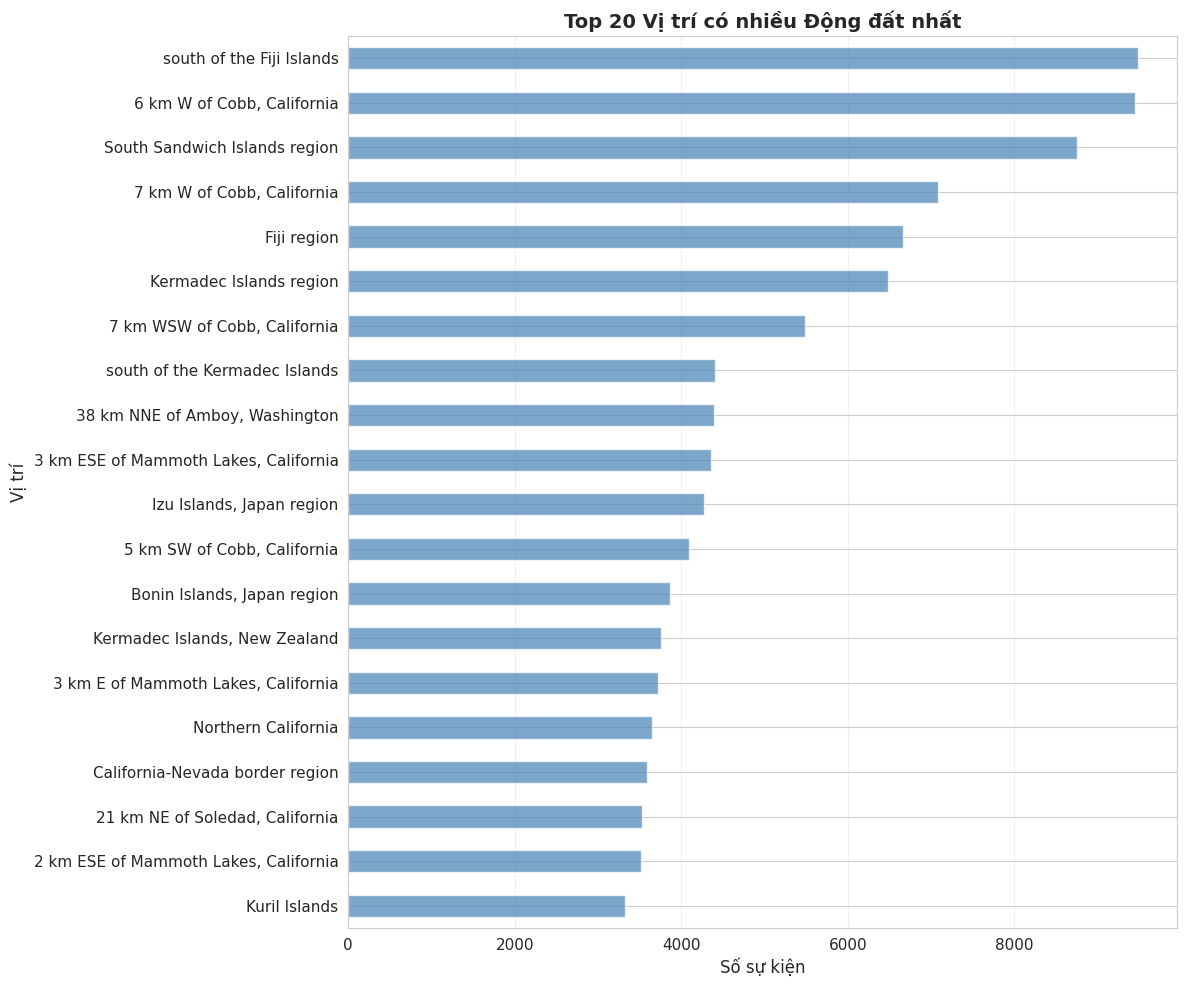


TOP 20 VỊ TRÍ:
------------------------------------------------------------
   1. south of the Fiji Islands: 9,482
   2. 6 km W of Cobb, California: 9,447
   3. South Sandwich Islands region: 8,756
   4. 7 km W of Cobb, California: 7,087
   5. Fiji region: 6,670
   6. Kermadec Islands region: 6,479
   7. 7 km WSW of Cobb, California: 5,486
   8. south of the Kermadec Islands: 4,407
   9. 38 km NNE of Amboy, Washington: 4,397
  10. 3 km ESE of Mammoth Lakes, California: 4,360
  11. Izu Islands, Japan region: 4,270
  12. 5 km SW of Cobb, California: 4,094
  13. Bonin Islands, Japan region: 3,869
  14. Kermadec Islands, New Zealand: 3,757
  15. 3 km E of Mammoth Lakes, California: 3,723
  16. Northern California: 3,647
  17. California-Nevada border region: 3,584
  18. 21 km NE of Soledad, California: 3,529
  19. 2 km ESE of Mammoth Lakes, California: 3,520
  20. Kuril Islands: 3,319


In [20]:
# Top 20 vị trí có nhiều động đất nhất
top_locations = df['place'].value_counts().head(20)

plt.figure(figsize=(12, 10))
top_locations.sort_values().plot(kind='barh', color='steelblue', alpha=0.7)
plt.xlabel('Số sự kiện', fontsize=12)
plt.ylabel('Vị trí', fontsize=12)
plt.title('Top 20 Vị trí có nhiều Động đất nhất', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\nTOP 20 VỊ TRÍ:")
print("-" * 60)
for i, (place, count) in enumerate(top_locations.items(), 1):
    print(f"  {i:2d}. {place}: {count:,}")

## 10. CÁC CHỈ SỐ THỐNG KÊ QUAN TRỌNG

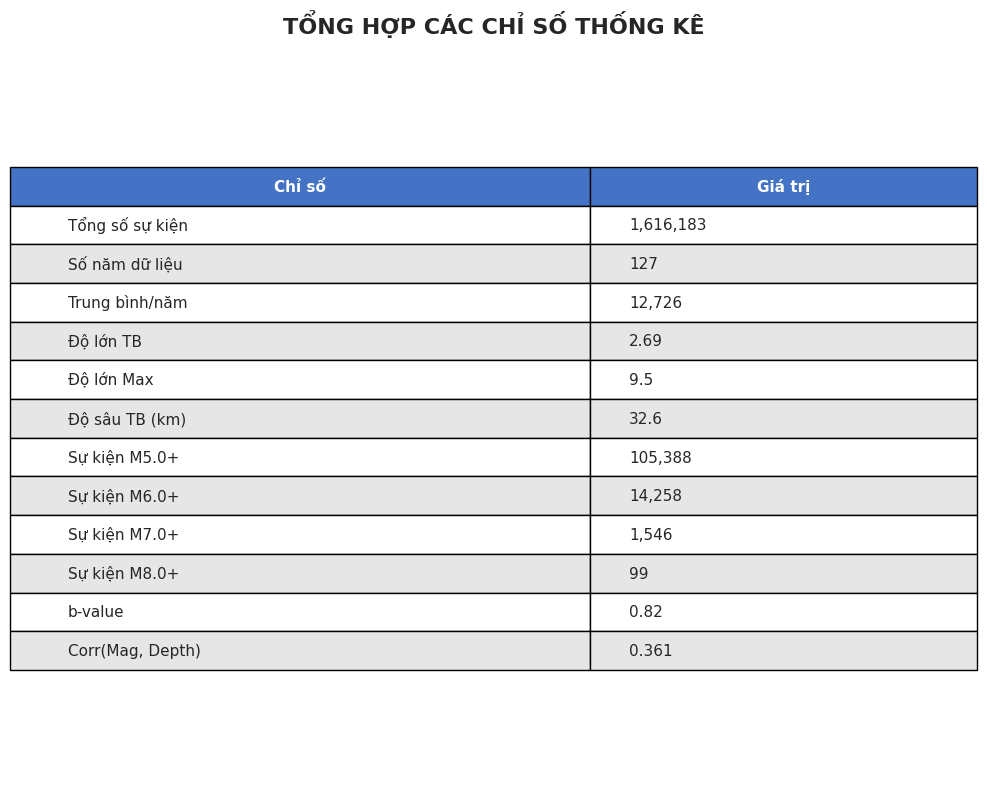

          Chỉ số   Giá trị
 Tổng số sự kiện 1,616,183
  Số năm dữ liệu       127
  Trung bình/năm    12,726
       Độ lớn TB      2.69
      Độ lớn Max       9.5
  Độ sâu TB (km)      32.6
   Sự kiện M5.0+   105,388
   Sự kiện M6.0+    14,258
   Sự kiện M7.0+     1,546
   Sự kiện M8.0+        99
         b-value      0.82
Corr(Mag, Depth)     0.361


In [21]:
# Tóm tắt các chỉ số chính
summary_stats = {
    'Chỉ số': [
        'Tổng số sự kiện',
        'Số năm dữ liệu',
        'Trung bình/năm',
        'Độ lớn TB',
        'Độ lớn Max',
        'Độ sâu TB (km)',
        'Sự kiện M5.0+',
        'Sự kiện M6.0+',
        'Sự kiện M7.0+',
        'Sự kiện M8.0+',
        'b-value',
        'Corr(Mag, Depth)'
    ],
    'Giá trị': [
        f"{total_events:,}",
        f"{num_years}",
        f"{total_events/num_years:,.0f}",
        f"{avg_mag:.2f}",
        f"{max_mag:.1f}",
        f"{avg_depth:.1f}",
        f"{len(df[df['mag'] >= 5.0]):,}",
        f"{len(df[df['mag'] >= 6.0]):,}",
        f"{len(df[df['mag'] >= 7.0]):,}",
        f"{len(df[df['mag'] >= 8.0]):,}",
        f"{b_value:.2f}",
        f"{corr:.3f}"
    ]
}

summary_df = pd.DataFrame(summary_stats)

plt.figure(figsize=(10, 8))
plt.axis('off')
table = plt.table(cellText=summary_df.values,
                  colLabels=summary_df.columns,
                  cellLoc='left',
                  loc='center',
                  colWidths=[0.6, 0.4])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2)

# Style header
for i in range(len(summary_df.columns)):
    table[(0, i)].set_facecolor('#4472C4')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Style alternate rows
for i in range(1, len(summary_df) + 1):
    if i % 2 == 0:
        for j in range(len(summary_df.columns)):
            table[(i, j)].set_facecolor('#E7E6E6')

plt.title('TỔNG HỢP CÁC CHỈ SỐ THỐNG KÊ', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print(summary_df.to_string(index=False))

## 11. KẾT LUẬN VÀ NHẬN XÉT

In [22]:
print("="*80)
print("KẾT LUẬN PHÂN TÍCH DỮ LIỆU ĐỘNG ĐẤT")
print("="*80)

print("\n1. ĐẶC ĐIỂM DỮ LIỆU:")
print(f"   - Dataset chứa {total_events:,} sự kiện động đất từ {num_years} năm ({year_range})")
print(f"   - Trung bình {total_events/num_years:,.0f} sự kiện mỗi năm")

print("\n2. PHÂN PHỐI ĐỘ LỚN:")
print(f"   - Đa số là động đất nhỏ (< M4.0): {len(df[df['mag'] < 4.0])/len(df)*100:.1f}%")
print(f"   - Động đất đáng nguy hiểm (M5.0+): {len(df[df['mag'] >= 5.0]):,} ({len(df[df['mag'] >= 5.0])/len(df)*100:.2f}%)")
print(f"   - Động đất lớn (M7.0+): {len(df[df['mag'] >= 7.0]):,} ({len(df[df['mag'] >= 7.0])/len(df)*100:.2f}%)")
print(f"   - Siêu động đất (M8.0+): {len(df[df['mag'] >= 8.0]):,} ({len(df[df['mag'] >= 8.0])/len(df)*100:.3f}%)")

print("\n3. PHÂN PHỐI ĐỘ SÂU:")
print(f"   - Đa số là động đất nông (< 35km): {len(df[df['depth'] < 35])/len(df)*100:.1f}%")
print(f"   - Động đất trung bình (35-70km): {len(df[(df['depth'] >= 35) & (df['depth'] < 70)])/len(df)*100:.1f}%")
print(f"   - Động đất sâu (> 70km): {len(df[df['depth'] >= 70])/len(df)*100:.1f}%")

print("\n4. XU HƯỚNG THỜI GIAN:")
if slope > 100:
    print(f"   - CÓ xu hướng TĂNG rõ rệt ({slope:.0f} sự kiện/năm)")
    print(f"     → Có thể do hệ thống ghi nhận được cải thiện theo thời gian")
elif slope < -100:
    print(f"   - Có xu hướng GIẢM ({slope:.0f} sự kiện/năm)")
else:
    print(f"   - KHÔNG có xu hướng rõ rệt")

print("\n5. GUTENBERG-RICHTER LAW:")
print(f"   - b-value = {b_value:.2f} (trong khoảng điển hình 0.8-1.2)")
print(f"   - Mối quan hệ: log10(N) = {a_value:.2f} - {b_value:.2f}*M")
print(f"   - Mỗi tăng 1 độ lớn → số lượng giảm {10**b_value:.1f} lần")

print("\n6. MỐI TƯƠNG QUAN:")
print(f"   - Correlation(Mag, Depth) = {corr:.3f}")
print(f"   - Độ lớn và độ sâu KHÔNG có mối tương quan mạnh")

print("\n" + "="*80)

KẾT LUẬN PHÂN TÍCH DỮ LIỆU ĐỘNG ĐẤT

1. ĐẶC ĐIỂM DỮ LIỆU:
   - Dataset chứa 1,616,183 sự kiện động đất từ 127 năm (1900 - 2026)
   - Trung bình 12,726 sự kiện mỗi năm

2. PHÂN PHỐI ĐỘ LỚN:
   - Đa số là động đất nhỏ (< M4.0): 67.2%
   - Động đất đáng nguy hiểm (M5.0+): 105,388 (6.52%)
   - Động đất lớn (M7.0+): 1,546 (0.10%)
   - Siêu động đất (M8.0+): 99 (0.006%)

3. PHÂN PHỐI ĐỘ SÂU:
   - Đa số là động đất nông (< 35km): 82.3%
   - Động đất trung bình (35-70km): 7.5%
   - Động đất sâu (> 70km): 10.2%

4. XU HƯỚNG THỜI GIAN:
   - KHÔNG có xu hướng rõ rệt

5. GUTENBERG-RICHTER LAW:
   - b-value = 0.82 (trong khoảng điển hình 0.8-1.2)
   - Mối quan hệ: log10(N) = 8.59 - 0.82*M
   - Mỗi tăng 1 độ lớn → số lượng giảm 6.6 lần

6. MỐI TƯƠNG QUAN:
   - Correlation(Mag, Depth) = 0.361
   - Độ lớn và độ sâu KHÔNG có mối tương quan mạnh



In [23]:
# Gợi ý cho Khai phá dữ liệu (Data Mining)
print("\n" + "="*80)
print("GỢI Ý CÁC ĐỀ TÀI KHAI PHÁ DỮ LIỆU (DATA MINING)")
print("="*80)

print("\n📊 Cấp độ 1 - EDA cơ bản:")
print("   1. Phân tích xu hướng động đất theo thập kỷ")
print("   2. So sánh đặc điểm động đất giữa các vùng địa lý")
print("   3. Phân tích seasonal patterns (mùa, quý)")

print("\n🔍 Cấp độ 2 - Pattern Mining:")
print("   4. Phát hiện foreshock/aftershock sequences")
print("   5. Clustering động đất theo đặc điểm khu vực")
print("   6. Tìm association rules giữa vị trí và độ lớn")

print("\n🤖 Cấp độ 3 - Prediction:")
print("   7. Dự báo số lượng động đất theo thời gian")
print("   8. Dự báo độ lớn động đất tiếp theo")
print("   9. Phát hiện seismic quiescence (giai đoạn yên tĩnh)")
print("  10. Mô hình hóa earthquake sequences")

print("\n" + "="*80)


GỢI Ý CÁC ĐỀ TÀI KHAI PHÁ DỮ LIỆU (DATA MINING)

📊 Cấp độ 1 - EDA cơ bản:
   1. Phân tích xu hướng động đất theo thập kỷ
   2. So sánh đặc điểm động đất giữa các vùng địa lý
   3. Phân tích seasonal patterns (mùa, quý)

🔍 Cấp độ 2 - Pattern Mining:
   4. Phát hiện foreshock/aftershock sequences
   5. Clustering động đất theo đặc điểm khu vực
   6. Tìm association rules giữa vị trí và độ lớn

🤖 Cấp độ 3 - Prediction:
   7. Dự báo số lượng động đất theo thời gian
   8. Dự báo độ lớn động đất tiếp theo
   9. Phát hiện seismic quiescence (giai đoạn yên tĩnh)
  10. Mô hình hóa earthquake sequences



---

**Lưu ý:** 
- Chạy `python aggregate_data.py` trước để tạo file `data_summary.csv`
- Dataset lấy từ USGS Earthquake Catalog
- File visualize.ipynb dùng cho Jupyter Notebook hoặc VS Code